<a href="https://colab.research.google.com/github/DilakshanRahul12/CM2604/blob/Ensemble/EnsembleModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')
dataset = '/content/drive/MyDrive/CM2604/dataset/bank-additional/bank-additional-full.csv'
df = pd.read_csv(dataset, sep=';')
df.head()

Mounted at /content/drive


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Data Preprocessing

In [28]:
#duration
df_dur = df[df['duration'] < 814].copy()
df_dur.shape
#age
df_dur['age'] = df_dur['age'].apply(lambda x: 66 if x > 66 else x)
#campaign
df_dur['campaign'] = np.log1p(df_dur['campaign'])
#pdays
def categorize_pdays(pdays):
    if 0 <= pdays <= 30:
        return 'recently contacted'
    elif 31 <= pdays <= 90:
        return 'contacted few months ago'
    elif 91 <= pdays <= 998:
        return 'contacted long ago'
    elif pdays == 999:
        return 'not contacted'
# Apply the function to create the new categorical feature
df_dur['pdays'] = df_dur['pdays'].apply(categorize_pdays)
#previous
df_dur['previous'] = np.log1p(df_dur['previous'])

df_handled = df_dur.copy()

df_handled['duration'] = np.log1p(df_handled['duration'])  # log(1 + x) for duration

df_encoded1 = df_handled.copy()


# --- ENCODE ---


from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoders and store mappings
label_encoders = {}
mappings = {}
# Iterate through categorical columns
for column in df_encoded1.select_dtypes(include=['object']):
    le = LabelEncoder()
    df_encoded1[column] = le.fit_transform(df_encoded1[column])
    label_encoders[column] = le
    mappings[column] = dict(zip(le.classes_, le.transform(le.classes_)))

# Display the mappings
# for column, mapping in mappings.items():
#     print(f"Mappings for column '{column}':")
#     print(mapping)
#     print("---")

df_feat = df_encoded1.copy()

RF Preprocess

In [29]:
df_dt_rf = df_feat.copy()

ANN Preprocess

In [30]:
df_dt_ann = df_feat.copy()

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

correlated_features = ['emp.var.rate', 'euribor3m', 'nr.employed', 'cons.price.idx']
# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_dt_ann[correlated_features])

pca = PCA(n_components=1)
pca_component = pca.fit_transform(scaled_features)
#PCA component to the dataframe and drop original features
df_dt_ann['econ.idx'] = pca_component
df_dt_ann.drop(columns=correlated_features, inplace=True)


# Combine pdays and previous
df_dt_ann['pdays_previous_ratio'] = df_dt_ann['pdays'] / (df_dt_ann['previous'] + 1)  # Avoid division by zero
df_dt_ann.drop(columns=['pdays', 'previous'], inplace=True)

In [32]:
features_to_scale = df_dt_ann.drop('y', axis=1).columns
scaler = StandardScaler()
df_dt_ann[features_to_scale] = scaler.fit_transform(df_dt_ann[features_to_scale])

In [33]:
df_dt_ann.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,poutcome,cons.conf.idx,y,econ.idx,pdays_previous_ratio
0,1.607096,-0.202991,-0.28187,-1.753954,-0.513501,-1.088374,-0.451735,1.314745,0.761512,-0.717842,0.557129,-0.862359,0.19554,0.883595,0,0.648961,-0.192473
1,1.706958,0.908786,-0.28187,-0.350203,1.945627,-1.088374,-0.451735,1.314745,0.761512,-0.717842,-0.098732,-0.862359,0.19554,0.883595,0,0.648961,-0.192473
2,-0.290287,0.908786,-0.28187,-0.350203,-0.513501,0.941613,-0.451735,1.314745,0.761512,-0.717842,0.388498,-0.862359,0.19554,0.883595,0,0.648961,-0.192473
3,0.009300,-1.036825,-0.28187,-1.286037,-0.513501,-1.088374,-0.451735,1.314745,0.761512,-0.717842,-0.083155,-0.862359,0.19554,0.883595,0,0.648961,-0.192473
4,1.607096,0.908786,-0.28187,-0.350203,-0.513501,-1.088374,2.315841,1.314745,0.761512,-0.717842,0.747351,-0.862359,0.19554,0.883595,0,0.648961,-0.192473


## RF MODELS

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Assuming df_dt is your preprocessed DataFrame and 'y' is your target variable column
X = df_dt_rf.drop('y', axis=1)
y = df_dt_rf['y']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

### RF1 (normal)

In [178]:
rf1 = RandomForestClassifier()
rf1.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf1.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9300088596380205
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7178
           1       0.66      0.48      0.56       723

    accuracy                           0.93      7901
   macro avg       0.81      0.73      0.76      7901
weighted avg       0.92      0.93      0.93      7901



### RF2 (OverSampling)

In [179]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state=11,sampling_strategy='minority')
X_resampled, y_resampled = oversampler.fit_resample(X_train, y_train)

from sklearn.ensemble import RandomForestClassifier

# Initialize and train a RandomForestClassifier
rf2 = RandomForestClassifier(n_estimators=100, random_state=11)  # Adjust n_estimators as needed
rf2.fit(X_resampled, y_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf2.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier: {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Accuracy of Random Forest Classifier: 0.9245665105682825
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7178
           1       0.59      0.59      0.59       723

    accuracy                           0.92      7901
   macro avg       0.77      0.77      0.77      7901
weighted avg       0.92      0.92      0.92      7901



### RF3 (Undersampling)

In [180]:
from imblearn.under_sampling import RandomUnderSampler

X_resampled, y_resampled = RandomUnderSampler(random_state=11,sampling_strategy='not minority').fit_resample(X_train, y_train)

# Initialize and train a RandomForestClassifier (or your preferred model)
rf3 = RandomForestClassifier(n_estimators=100, random_state=11)
rf3.fit(X_resampled, y_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf3.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier (Undersampled): {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Accuracy of Random Forest Classifier (Undersampled): 0.8543222376914315
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      7178
           1       0.38      0.93      0.54       723

    accuracy                           0.85      7901
   macro avg       0.69      0.89      0.73      7901
weighted avg       0.94      0.85      0.88      7901



### RF4 (SMOTE)

In [181]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42) # Added random_state for reproducibility
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Initialize and train a RandomForestClassifier
rf4 = RandomForestClassifier(n_estimators=100, random_state=11)
rf4.fit(X_train_resampled, y_train_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf4.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier (SMOTE): {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Accuracy of Random Forest Classifier (SMOTE): 0.9217820529046956
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7178
           1       0.56      0.64      0.60       723

    accuracy                           0.92      7901
   macro avg       0.76      0.80      0.78      7901
weighted avg       0.93      0.92      0.92      7901



### RF5 Hyperparameterized

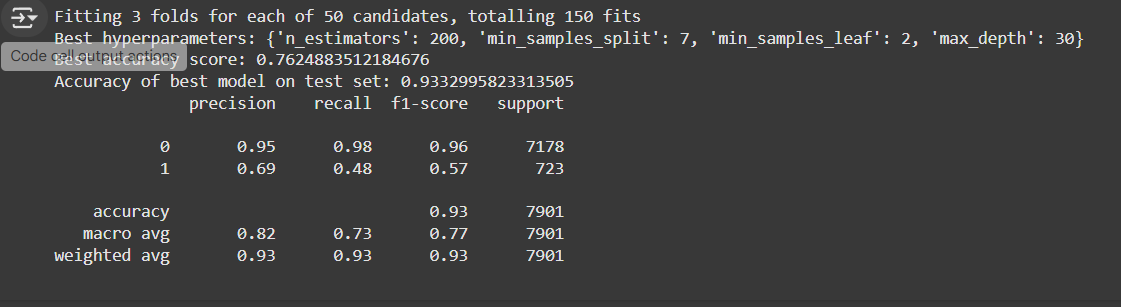

In [182]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the RandomForestClassifier with the best hyperparameters
rf5 = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=2,
    max_depth=30,
    random_state=11
    )

# Train the model on the training data
rf5.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf5.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.9320339197569928
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7178
           1       0.68      0.49      0.57       723

    accuracy                           0.93      7901
   macro avg       0.81      0.73      0.77      7901
weighted avg       0.93      0.93      0.93      7901



## ANN MODELS

In [34]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Assuming df_dt is your preprocessed DataFrame and 'y' is your target variable column
X = df_dt_ann.drop('y', axis=1)
y = df_dt_ann['y']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=11)

# Apply SMOTE to the training data
smote = SMOTE(random_state=11,sampling_strategy='minority')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
from tensorflow.keras.optimizers import Adam

In [11]:
# Define a function to build and compile the model
def ANN1(activation):
    model = Sequential([
        Dense(64, activation=activation, input_dim=X_train_resampled.shape[1]),
        Dropout(0.3),
        Dense(64, activation=activation),
        Dropout(0.3),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

without SMOTE

In [12]:
# Train with ReLU
relu = ANN1('relu')
history_relu = relu.fit(X_train, y_train, validation_split=0.2, epochs=10, batch_size=32, verbose=1)

# Get predictions on the test set
y_pred_prob = relu.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


741/741 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - AUC: 0.4996 - loss: 30.6015 - val_AUC: 0.7550 - val_loss: 0.4085
Epoch 2/10


KeyboardInterrupt: 

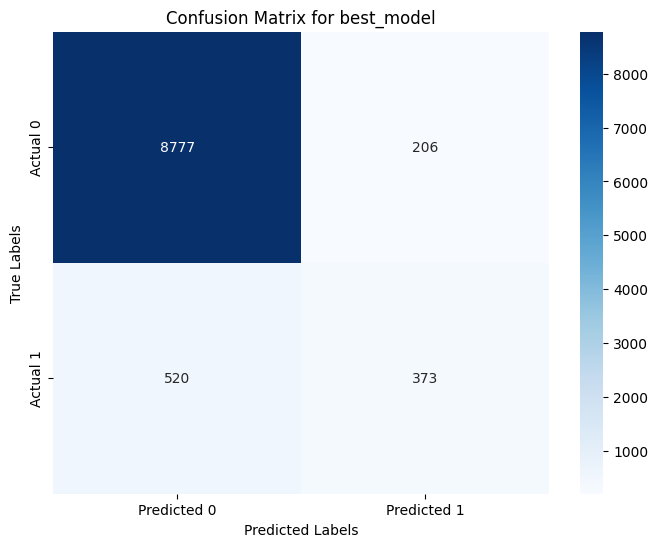


Classification Report for best_model:
              precision    recall  f1-score   support

     Class 0       0.94      0.98      0.96      8983
     Class 1       0.64      0.42      0.51       893

    accuracy                           0.93      9876
   macro avg       0.79      0.70      0.73      9876
weighted avg       0.92      0.93      0.92      9876



In [82]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix for best_model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Print the classification report
print("\nClassification Report for best_model:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

### ANN1 Improved with smote

In [36]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

# After applying SMOTE
X_train_resampled, X_val, y_train_resampled, y_val = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.2, random_state=11
)

# Build and compile the model
def ANN1(activation):
    model = Sequential([
        Dense(64, activation=activation, input_dim=X_train_resampled.shape[1]),
        Dropout(0.3),
        Dense(64, activation=activation),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[AUC(name='AUC')])
    return model

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
relu1 = ANN1('relu')
history_relu = relu1.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=10, batch_size=32, verbose=1,
    callbacks=[early_stop]
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1343/1343 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - AUC: 0.8825 - loss: 0.4191 - val_AUC: 0.9421 - val_loss: 0.2954
Epoch 2/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - AUC: 0.9337 - loss: 0.3121 - val_AUC: 0.9468 - val_loss: 0.2808
Epoch 3/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - AUC: 0.9382 - loss: 0.2966 - val_AUC: 0.9501 - val_loss: 0.2670
Epoch 4/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.9419 - loss: 0.2861 - val_AUC: 0.9533 - val_loss: 0.2602
Epoch 5/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - AUC: 0.9438 - loss: 0.2785 - val_AUC: 0.9559 - val_loss: 0.2482
Epoch 6/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - AUC: 0.9483 - loss: 0.2679 - val_AUC: 0.9574 - val_loss: 0.2430
Epoch 7/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9509 - loss: 0.2613 - val_AUC: 0.9593 - val_loss: 0.2377
Epoch 8/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - AUC: 0.9519 - loss: 0.2552 - val_AUC: 0.9587 - val_loss: 0.2383
Epoch 9/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/st

309/309 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


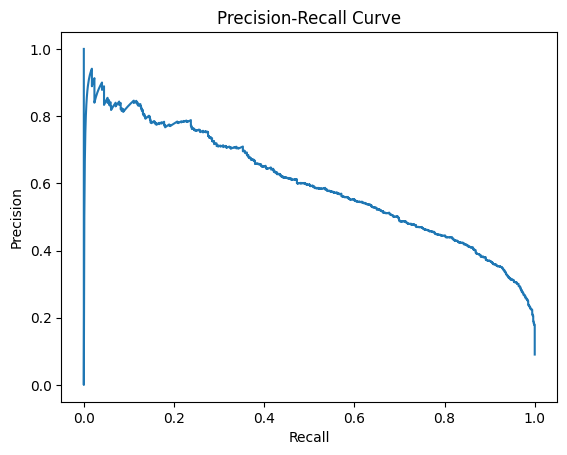

In [86]:
from sklearn.metrics import precision_recall_curve

y_probs = relu1.predict(X_test)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Plot Precision-Recall Curve
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [122]:
y_pred = (y_pred_prob > 0.5).astype(int)
new_threshold = 0.845
y_pred_new = (y_probs >= new_threshold).astype(int)

In [123]:
# Evaluate predictions
accuracy = accuracy_score(y_test, y_pred_new)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report OLD:")
print(classification_report(y_test, y_pred))
print("Classification Report NEW:")
print(classification_report(y_test, y_pred_new))

Accuracy: 0.9192
Classification Report OLD:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      8983
           1       0.38      0.90      0.53       893

    accuracy                           0.86      9876
   macro avg       0.68      0.88      0.72      9876
weighted avg       0.93      0.86      0.88      9876

Classification Report NEW:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      8983
           1       0.55      0.60      0.57       893

    accuracy                           0.92      9876
   macro avg       0.75      0.78      0.76      9876
weighted avg       0.92      0.92      0.92      9876



### Validation Spilit

In [57]:
# After applying SMOTE
X_train_resampled, X_val, y_train_resampled, y_val = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.15, random_state=11)

### ANN2 (hyperparamtered)

In [37]:
# Build and compile the model
def ANN2(activation):
    model = Sequential([
        Dense(128, activation=activation, input_dim=X_train.shape[1]),
        Dropout(0.2),
        Dense(128, activation=activation),
        Dropout(0),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    opt = Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['AUC'])
    return model

In [38]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train with ReLU activation function
relu2 = ANN2('relu')
history_relu = relu2.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=10, batch_size=32, verbose=1,
    callbacks=[early_stop]
)

# Predict probabilities on the test set
y_pred_prob = relu2.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.88).astype(int)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1343/1343 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.9177 - loss: 0.3533 - val_AUC: 0.9485 - val_loss: 0.2725
Epoch 2/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9446 - loss: 0.2800 - val_AUC: 0.9554 - val_loss: 0.2487
Epoch 3/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.9514 - loss: 0.2579 - val_AUC: 0.9591 - val_loss: 0.2364
Epoch 4/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - AUC: 0.9553 - loss: 0.2477 - val_AUC: 0.9629 - val_loss: 0.2234
Epoch 5/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9574 - loss: 0.2370 - val_AUC: 0.9637 - val_loss: 0.2222
Epoch 6/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.9597 - loss: 0.2313 - val_AUC: 0.9649 - val_loss: 0.2165
Epoch 7/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9639 - loss: 0.2195 - val_AUC: 0.9670 - val_loss: 0.2116
Epoch 8/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - AUC: 0.9661 - loss: 0.2099 - val_AUC: 0.9677 - val_loss: 0.2128
Epoch 9/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/st

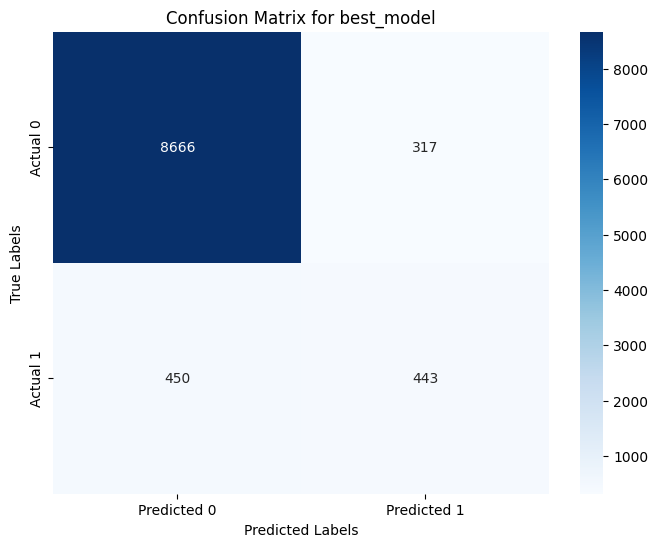


Accuracy: 0.9223


Classification Report for best_model:
              precision    recall  f1-score   support

     Class 0       0.95      0.96      0.96      8983
     Class 1       0.58      0.50      0.54       893

    accuracy                           0.92      9876
   macro avg       0.77      0.73      0.75      9876
weighted avg       0.92      0.92      0.92      9876



In [164]:
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix for best_model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Evaluate predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}\n")

# Print the classification report
print("\nClassification Report for best_model:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

### ANN3 My validation

In [39]:
def ANN3(activation='relu'):
    model = Sequential([
        Dense(128, activation=activation, input_dim=X_train.shape[1]),
        Dropout(0.2),
        Dense(128, activation=activation),
        Dropout(0.1),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    opt = Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['AUC'])
    return model

In [40]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train with ReLU activation function
relu3 = ANN3('relu')
history_relu = relu3.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=10, batch_size=32, verbose=1,
    callbacks=[early_stop]
)

# Predict probabilities on the test set
y_pred_prob = relu3.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.8).astype(int)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1343/1343 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.9155 - loss: 0.3596 - val_AUC: 0.9493 - val_loss: 0.2715
Epoch 2/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.9444 - loss: 0.2829 - val_AUC: 0.9568 - val_loss: 0.2498
Epoch 3/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.9521 - loss: 0.2598 - val_AUC: 0.9604 - val_loss: 0.2372
Epoch 4/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.9557 - loss: 0.2467 - val_AUC: 0.9615 - val_loss: 0.2305
Epoch 5/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - AUC: 0.9581 - loss: 0.2377 - val_AUC: 0.9623 - val_loss: 0.2326
Epoch 6/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - AUC: 0.9620 - loss: 0.2258 - val_AUC: 0.9641 - val_loss: 0.2201
Epoch 7/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - AUC: 0.9614 - loss: 0.2257 - val_AUC: 0.9651 - val_loss: 0.2160
Epoch 8/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - AUC: 0.9619 - loss: 0.2251 - val_AUC: 0.9668 - val_loss: 0.2123
Epoch 9/10
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/st

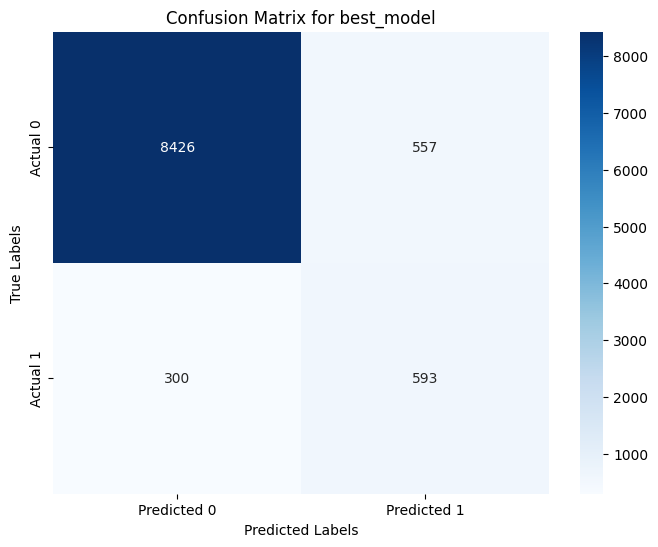


Accuracy: 0.9132


Classification Report for best_model:
              precision    recall  f1-score   support

     Class 0       0.97      0.94      0.95      8983
     Class 1       0.52      0.66      0.58       893

    accuracy                           0.91      9876
   macro avg       0.74      0.80      0.77      9876
weighted avg       0.92      0.91      0.92      9876



In [149]:
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix for best_model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Evaluate predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}\n")

# Print the classification report
print("\nClassification Report for best_model:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

### ANN4 (Undersampled)

In [41]:
from imblearn.under_sampling import RandomUnderSampler

X_resampled, y_resampled = RandomUnderSampler(random_state=11,sampling_strategy='not minority').fit_resample(X_train, y_train)

X_train_resampled, X_val, y_train_resampled, y_val = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.15, random_state=11)

# Build and compile the model
def ANN4(activation):
    model = Sequential([
        Dense(128, activation=activation, input_dim=X_train.shape[1]),
        Dropout(0.2),
        Dense(128, activation=activation),
        Dropout(0),
        Dense(1, activation='sigmoid')  # Binary classification
    ])

    opt = Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['AUC'])
    return model

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [42]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train with ReLU activation function
relu4 = ANN4('relu')
history_relu = relu4.fit(
    X_train_resampled, y_train_resampled,
    validation_data=(X_val, y_val),
    epochs=10, batch_size=32, verbose=1,
    callbacks=[early_stop]
)

# Predict probabilities on the test set
y_pred_prob = relu4.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.8).astype(int)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1142/1142 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.9131 - loss: 0.3635 - val_AUC: 0.9497 - val_loss: 0.2643
Epoch 2/10
1142/1142 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.9445 - loss: 0.2822 - val_AUC: 0.9550 - val_loss: 0.2486
Epoch 3/10
1142/1142 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.9511 - loss: 0.2604 - val_AUC: 0.9589 - val_loss: 0.2396
Epoch 4/10
1142/1142 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9544 - loss: 0.2506 - val_AUC: 0.9626 - val_loss: 0.2245
Epoch 5/10
1142/1142 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.9576 - loss: 0.2397 - val_AUC: 0.9633 - val_loss: 0.2256
Epoch 6/10
1142/1142 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.9609 - loss: 0.2288 - val_AUC: 0.9652 - val_loss: 0.2139
Epoch 7/10
1142/1142 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9621 - loss: 0.2243 - val_AUC: 0.9657 - val_loss: 0.2110
Epoch 8/10
1142/1142 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9635 - loss: 0.2205 - val_AUC: 0.9667 - val_loss: 0.2055
Epoch 9/10
1142/1142 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/st

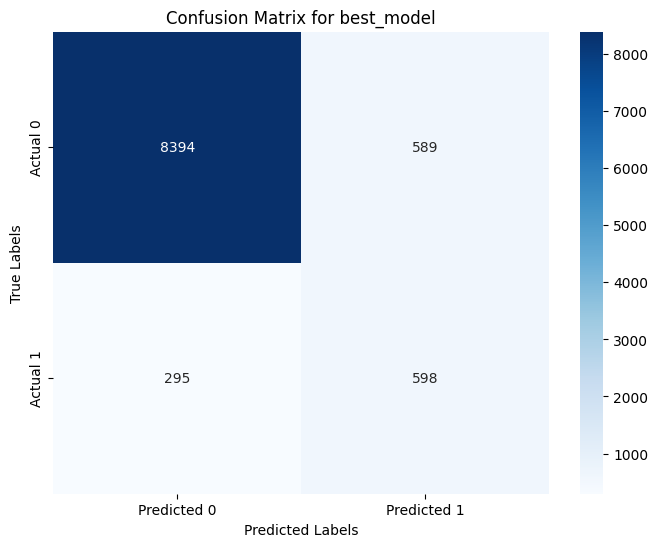


Accuracy: 0.9105


Classification Report for best_model:
              precision    recall  f1-score   support

     Class 0       0.97      0.93      0.95      8983
     Class 1       0.50      0.67      0.57       893

    accuracy                           0.91      9876
   macro avg       0.73      0.80      0.76      9876
weighted avg       0.92      0.91      0.92      9876



In [152]:
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix for best_model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Evaluate predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}\n")

# Print the classification report
print("\nClassification Report for best_model:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

## Ensemble Model

In [43]:
df = df_dt_ann.copy()
X = df.drop('y', axis=1)
y = df['y']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

#### RF1

In [47]:
rf1 = RandomForestClassifier()
rf1.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf1.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.931907353499557
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7178
           1       0.68      0.49      0.57       723

    accuracy                           0.93      7901
   macro avg       0.81      0.73      0.77      7901
weighted avg       0.92      0.93      0.93      7901



#### RF2

In [48]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state=11,sampling_strategy='minority')
X_resampled, y_resampled = oversampler.fit_resample(X_train, y_train)

from sklearn.ensemble import RandomForestClassifier

# Initialize and train a RandomForestClassifier
rf2 = RandomForestClassifier(n_estimators=100, random_state=11)  # Adjust n_estimators as needed
rf2.fit(X_resampled, y_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf2.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier: {accuracy_rf}")
print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Accuracy of Random Forest Classifier: 0.9245665105682825
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7178
           1       0.59      0.59      0.59       723

    accuracy                           0.92      7901
   macro avg       0.77      0.77      0.77      7901
weighted avg       0.92      0.92      0.92      7901



#### RF3

In [49]:
from imblearn.under_sampling import RandomUnderSampler

X_resampled, y_resampled = RandomUnderSampler(random_state=11,sampling_strategy='not minority').fit_resample(X_train, y_train)

# Initialize and train a RandomForestClassifier (or your preferred model)
rf3 = RandomForestClassifier(n_estimators=100, random_state=11)
rf3.fit(X_resampled, y_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf3.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier (Undersampled): {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Accuracy of Random Forest Classifier (Undersampled): 0.8543222376914315
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      7178
           1       0.38      0.93      0.54       723

    accuracy                           0.85      7901
   macro avg       0.69      0.89      0.73      7901
weighted avg       0.94      0.85      0.88      7901



#### RF4

In [50]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
smote = SMOTE(random_state=42) # Added random_state for reproducibility
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Initialize and train a RandomForestClassifier
rf4 = RandomForestClassifier(n_estimators=100, random_state=11)
rf4.fit(X_train_resampled, y_train_resampled)

# Make predictions and evaluate the model
y_pred_rf = rf4.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of Random Forest Classifier (SMOTE): {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Accuracy of Random Forest Classifier (SMOTE): 0.9217820529046956
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7178
           1       0.56      0.64      0.60       723

    accuracy                           0.92      7901
   macro avg       0.76      0.80      0.78      7901
weighted avg       0.93      0.92      0.92      7901



In [51]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier with the best hyperparameters
rf5 = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=2,
    max_depth=30,
    random_state=11
    )

# Train the model on the training data
rf5.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf5.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9320339197569928
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      7178
           1       0.68      0.49      0.57       723

    accuracy                           0.93      7901
   macro avg       0.81      0.73      0.77      7901
weighted avg       0.93      0.93      0.93      7901



Stack

In [52]:
# Collect predictions for X_test

rf1_probs = rf1.predict_proba(X_test)[:, 1]  # RF1
rf2_probs = rf2.predict_proba(X_test)[:, 1]  # RF2
rf3_probs = rf3.predict_proba(X_test)[:, 1]  # RF3
rf4_probs = rf4.predict_proba(X_test)[:, 1]  # RF4
rf5_probs = rf5.predict_proba(X_test)[:, 1]  # RF5

ann1_probs = relu1.predict(X_test).flatten()  # ANN1 probabilities
ann2_probs = relu2.predict(X_test).flatten()  # ANN2 probabilities
ann3_probs = relu3.predict(X_test).flatten()  # ANN3 probabilities
ann4_probs = relu4.predict(X_test).flatten()  # ANN4 probabilities

247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [53]:
# Stack predictions horizontally to form a new dataset
stacked_predictions = np.column_stack([
    rf1_probs, rf2_probs, rf3_probs, rf4_probs,
    ann1_probs, ann2_probs, ann3_probs, ann4_probs
])

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Train the meta-learner
meta_learner = LogisticRegression(random_state=11)
meta_learner.fit(stacked_predictions, y_test)

# Evaluate on the same test data
final_probs = meta_learner.predict_proba(stacked_predictions)[:, 1]
final_preds = (final_probs > 0.5).astype(int)

# Evaluate the performance
roc_auc = roc_auc_score(y_test, final_probs)
print(f"Stacked Model ROC AUC: {roc_auc}")
print(classification_report(y_test, final_preds))


Stacked Model ROC AUC: 0.9518803998848487
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7178
           1       0.63      0.50      0.56       723

    accuracy                           0.93      7901
   macro avg       0.79      0.74      0.76      7901
weighted avg       0.92      0.93      0.92      7901



#### PR curve

In [62]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, final_probs)

# Find the threshold that maximizes F1-score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)  # Avoid division by zero
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (F1-score): {optimal_threshold}")

# Apply the optimal threshold
final_preds1 = (final_probs >= optimal_threshold).astype(int)
final_preds2 = (final_probs >= 0.39).astype(int)

# Evaluate the performance with the new threshold
roc_auc = roc_auc_score(y_test, final_probs)
print(f"'nStacked Model ROC AUC: {roc_auc}")
print(classification_report(y_test, final_preds1))
print(f"'nStacked Model ROC AUC: {roc_auc}")
print(classification_report(y_test, final_preds2))

Optimal Threshold (F1-score): 0.3254171649701603
'nStacked Model ROC AUC: 0.9518803998848487
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      7178
           1       0.56      0.70      0.62       723

    accuracy                           0.92      7901
   macro avg       0.76      0.82      0.79      7901
weighted avg       0.93      0.92      0.93      7901

'nStacked Model ROC AUC: 0.9518803998848487
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7178
           1       0.59      0.64      0.61       723

    accuracy                           0.93      7901
   macro avg       0.78      0.80      0.78      7901
weighted avg       0.93      0.93      0.93      7901



ROC CURVE

In [71]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
# Generate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, final_probs)
# Calculate the distance to the top-left corner
distance = np.sqrt((1 - tpr)**2 + fpr**2)
optimal_idx = np.argmin(distance)  # Index of the optimal threshold
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (ROC): {optimal_threshold}")
# Apply the optimal threshold
final_preds1 = (final_probs >= optimal_threshold).astype(int)
final_preds2 = (final_probs >= 0.2).astype(int)
# Evaluate the performance
roc_auc = roc_auc_score(y_test, final_probs)
print(f"/nStacked Model ROC AUC: {roc_auc}")
print(classification_report(y_test, final_preds1))
# Evaluate the performance
roc_auc = roc_auc_score(y_test, final_probs)
print(f"/nStacked Model ROC AUC: {roc_auc}")
print(classification_report(y_test, final_preds2))

Optimal Threshold (ROC): 0.1108291977510314
/nStacked Model ROC AUC: 0.9518803998848487
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      7178
           1       0.43      0.90      0.58       723

    accuracy                           0.88      7901
   macro avg       0.71      0.89      0.75      7901
weighted avg       0.94      0.88      0.90      7901

/nStacked Model ROC AUC: 0.9518803998848487
              precision    recall  f1-score   support

           0       0.98      0.91      0.95      7178
           1       0.49      0.82      0.61       723

    accuracy                           0.90      7901
   macro avg       0.73      0.87      0.78      7901
weighted avg       0.94      0.90      0.91      7901



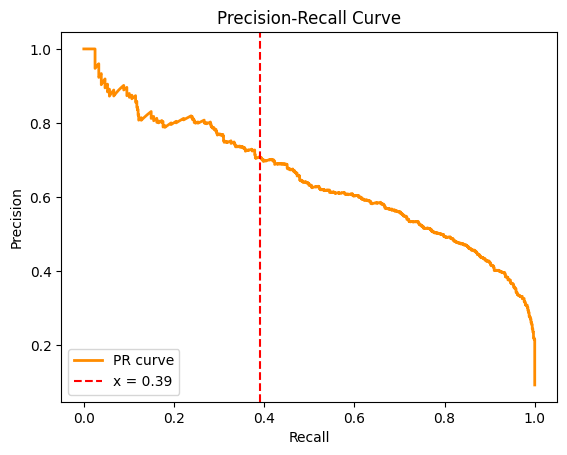

In [70]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PR curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.axvline(x=0.39, color='red', linestyle='--', label='x = 0.39') # Added vertical line
plt.legend(loc="lower left")
plt.show()

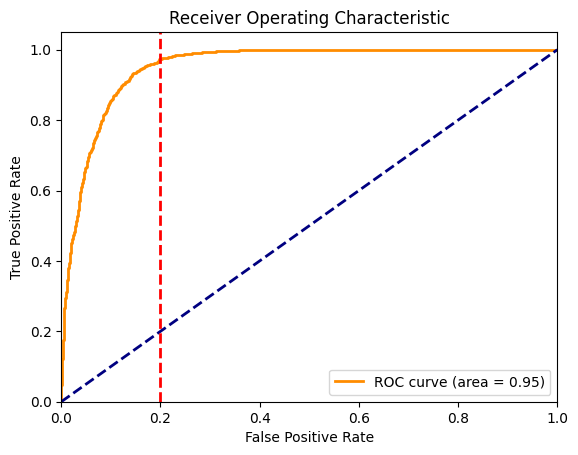

In [69]:
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, final_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.axvline(x=0.2, color='red', linestyle='--', linewidth=2) # Added line x = 0.2, bright red
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
# ... (rest of your code) ...

Gmeans ROC

In [76]:
# Generate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, final_probs)

# Calculate G-means
gmeans = np.sqrt(tpr * (1 - fpr))

# Find the optimal threshold (maximizing G-means)
optimal_idx = np.argmax(gmeans)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (G-means): {optimal_threshold}")
print(f"Maximum G-means: {gmeans[optimal_idx]}")

Optimal Threshold (G-means): 0.07249277088800772
Maximum G-means: 0.8940091307473739


In [77]:
# Apply the optimal threshold
final_preds = (final_probs >= optimal_threshold).astype(int)

# Evaluate the performance
from sklearn.metrics import classification_report, roc_auc_score

roc_auc = roc_auc_score(y_test, final_probs)
print(f"Stacked Model ROC AUC: {roc_auc}")
print(classification_report(y_test, final_preds))

Stacked Model ROC AUC: 0.9518803998848487
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7178
           1       0.40      0.93      0.56       723

    accuracy                           0.86      7901
   macro avg       0.69      0.89      0.74      7901
weighted avg       0.94      0.86      0.89      7901

